In [1]:
# %pip install causalml -q

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from causalml.inference.meta import BaseTRegressor, BaseSLearner, BaseXRegressor
from causalml.dataset import synthetic_data
from causalml.metrics import plot_gain, plot_qini

c:\Users\Niru\repos-for-cv\uplift-modelling-expt\causal-ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Failed to import duecredit due to No module named 'duecredit'


# Comparing the spurious treatment effect observed when confounding is not taken into account

<p> The difference of means is 0.9 - nearly +0.4 more than the actual difference of 0.4. This is caused by confounding. The "gold standard" method to remove spurious confounders is the Randomized Control Trial (RCT).</p>

In [3]:
naive, tlearn = [], []
for i in range(200):
    np.random.seed(i)
    #  mode=1 (for difficult nuisance components and an easy treatment effect.)
    # n=2000 (number of data samples)
    # p=5 (number of covariates)
    # sigma = 1 (variance of error term)
    y, X, treatment, tau, b, e = synthetic_data(mode=1, n=2000, p=5, sigma=1.0)
    # Returns:
    # y (outcome)
    # X (covariates)
    # treatment (W = 1/0)
    # tau (true treatment effect)
    # b (expected outcome)
    # e (propensity of receiving treatment)
    naive.append(y[treatment == 1].mean() - y[treatment == 0].mean())
    learner = BaseTRegressor(learner=GradientBoostingRegressor(random_state=i))
    ate, _, _ = learner.estimate_ate(X=X, treatment=treatment, y=y)
    tlearn.append(float(ate))

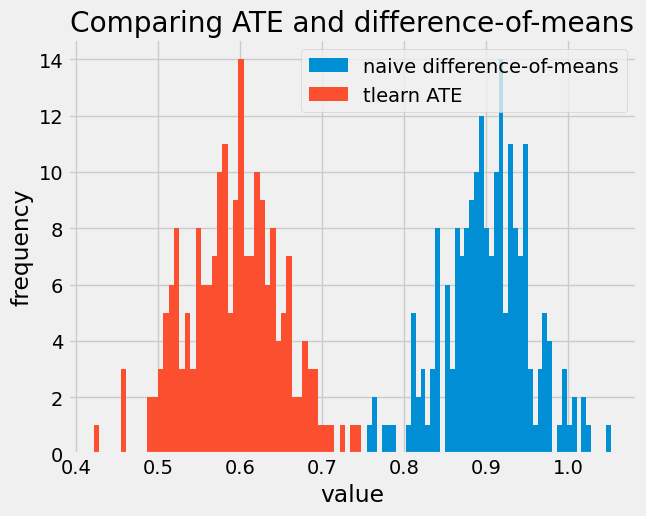

In [4]:
plt.hist(naive,bins=50,label='naive difference-of-means')
plt.hist(tlearn,bins=50,label='tlearn ATE')
plt.legend()
plt.tight_layout()
plt.title('Comparing ATE and difference-of-means')
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

# T-Learner from scratch

In [5]:
y, X, treatment, tau, b, e = synthetic_data(mode=1, n=2000, p=5, sigma=1.0)

In [6]:
print(f'The number of treated records is {np.sum(treatment)} out of the total number of records: {len(treatment)}.')

The number of treated records is 1018 out of the total number of records: 2000.


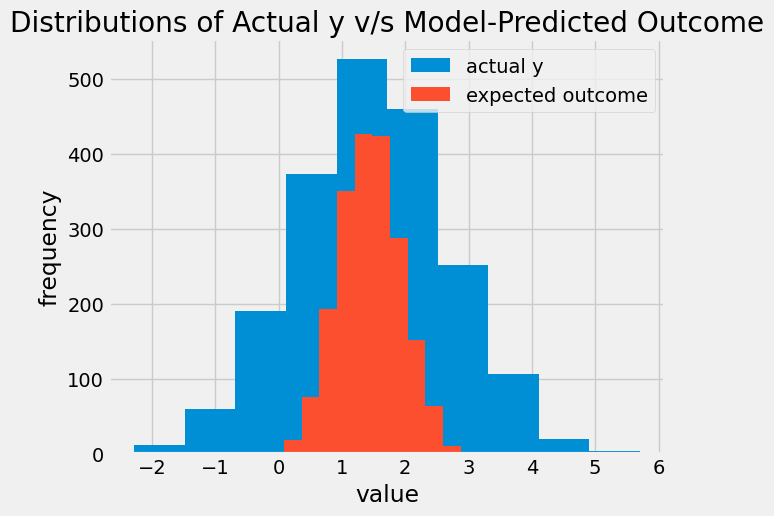

In [7]:
plt.hist(y,label='actual y')
plt.hist(b,label='expected outcome')
plt.legend()
plt.tight_layout()
plt.title('Distributions of Actual y v/s Model-Predicted Outcome')
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

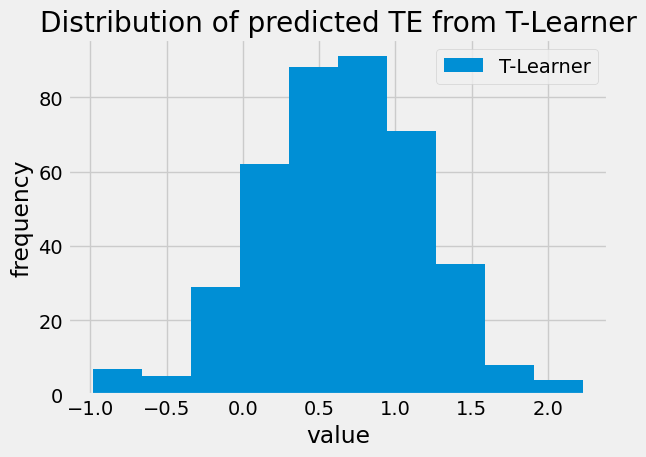

In [8]:
treatment_model = GradientBoostingRegressor()
control_model = GradientBoostingRegressor()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test,treatment_train,treatment_test = train_test_split(X,y,treatment,test_size=0.2,random_state=42)

X_train.shape,X_test.shape,y_train.shape,y_test.shape
treatment_X = X_train[treatment_train == 1]
treatment_y = y_train[treatment_train == 1]

control_X = X_train[treatment_train == 0]
control_y = y_train[treatment_train == 0]

treatment_model.fit(treatment_X, treatment_y)
control_model.fit(control_X, control_y)

te_pred = treatment_model.predict(X_test) - control_model.predict(X_test)

plt.hist(te_pred,label='T-Learner')
plt.xlabel('value')
plt.ylabel('frequency')
plt.title('Distribution of predicted TE from T-Learner')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
learner = BaseTRegressor(learner=GradientBoostingRegressor(random_state=42))
ate_lib, _, _ = learner.estimate_ate(X=X, treatment=treatment, y=y)

In [10]:
print(f'ATE from code: {te_pred.mean():.2}')
print(f'ATE from library function: {ate_lib.item():.2}')

ATE from code: 0.65
ATE from library function: 0.69


# S-Learner from scratch

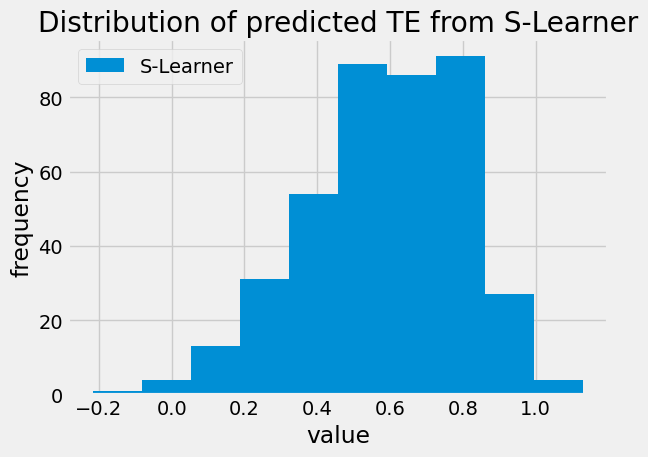

In [11]:
model = GradientBoostingRegressor()

X_train, X_test, y_train, y_test,treatment_train,treatment_test = train_test_split(X,y,treatment,test_size=0.2,random_state=42)
X_train_with_w = np.concat((X_train,treatment_train.reshape(1600,1)),axis=1)
model.fit(X_train_with_w, y_train)

x_dim = treatment_test.shape
X_test_with_w_1 = np.concat((X_test,np.ones((x_dim[0],1))),axis=1)
X_test_with_w_0 = np.concat((X_test,np.zeros((x_dim[0],1))),axis=1)

te_pred = model.predict(X_test_with_w_1) - model.predict(X_test_with_w_0)

plt.hist(te_pred,label='S-Learner')
plt.xlabel('value')
plt.ylabel('frequency')
plt.title('Distribution of predicted TE from S-Learner')
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
learner = BaseSLearner(learner=GradientBoostingRegressor(random_state=42))
ate_lib = learner.estimate_ate(X=X, treatment=treatment, y=y)

print(f'ATE from code: {te_pred.mean():.2}')
print(f'ATE from library function: {ate_lib.item():.2}')

ATE from code: 0.59
ATE from library function: 0.63


# X-Learner from Scratch

In [13]:
treatment_model = GradientBoostingRegressor(random_state=42)
control_model = GradientBoostingRegressor(random_state=42)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test,treatment_train,treatment_test,e_treatment,e_test = train_test_split(X,y,treatment,e,test_size=0.2,random_state=42)

X_train.shape,X_test.shape,y_train.shape,y_test.shape
treatment_X = X_train[treatment_train == 1]
treatment_y = y_train[treatment_train == 1]

control_X = X_train[treatment_train == 0]
control_y = y_train[treatment_train == 0]

treatment_model.fit(treatment_X, treatment_y)
control_model.fit(control_X, control_y)

# Imputed treatment effects 
d_treatment = treatment_y - control_model.predict(treatment_X)
d_control = treatment_model.predict(control_X) - control_y


# print(d_treatment.shape, d_control.shape)
imputed_treatment_model = GradientBoostingRegressor(random_state=42)
imputed_control_model  = GradientBoostingRegressor(random_state=42)

imputed_control_model.fit(control_X,d_control)
imputed_treatment_model.fit(treatment_X, d_treatment)

te_pred = imputed_control_model.predict(X_test)*e_test + imputed_treatment_model.predict(X_test)*(1-e_test)

In [14]:
learner = BaseXRegressor(learner=GradientBoostingRegressor(random_state=42))
ate_lib,_,_= learner.estimate_ate(X=X, treatment=treatment, y=y)

print(f'ATE from code: {te_pred.mean():.2}')
print(f'ATE from library function: {ate_lib.item():.2}')

ATE from code: 0.6
ATE from library function: 0.64


# Evaluation Measures for Causal Modelling

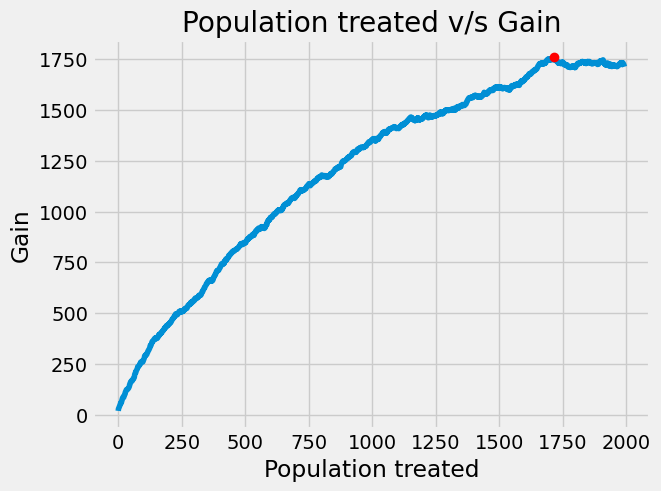

In [15]:
import pandas as pd, numpy as np
from causalml.metrics import plot_gain

learner = BaseXRegressor(learner=GradientBoostingRegressor(random_state=42))

y, X, treatment, tau, b, e = synthetic_data(mode=1, n=2000, p=5, sigma=1.0)
cate_x = learner.fit_predict(X=X,treatment=treatment,y=y)

cate_df = pd.DataFrame({
    'cate_x': cate_x.reshape(-1),
    'treatment' : treatment,
    'y' : y,
    'tau' : tau
}).sort_values(by='cate_x',ascending=False)

gain = []
y_running_sum_for_treatment = []
y_running_sum_for_control = []

for row in cate_df.itertuples():
    # print(row.cate_x)
    if row.treatment == 1:
        y_running_sum_for_treatment.append(row.y)
    else:
        y_running_sum_for_control.append(row.y)

    if len(y_running_sum_for_treatment) > 0 and len(y_running_sum_for_control) > 0:
        gain.append(
                (
                (np.sum(y_running_sum_for_treatment)/len(y_running_sum_for_treatment)) -\
                (np.sum(y_running_sum_for_control)/len(y_running_sum_for_control))
                ) * 
                (
                    len(y_running_sum_for_treatment) + len(y_running_sum_for_control)
                ) 
            )
plt.plot(gain)
plt.plot(np.argmax(gain),gain[np.argmax(gain)],'ro')
plt.xlabel('Population treated')
plt.ylabel('Gain')
plt.title('Population treated v/s Gain')
plt.show()

# Qini curve

In [19]:
# treatment_count = 0 
# control_count = 0
gain = []
cate_df = pd.DataFrame({
    'cate_x': cate_x.reshape(-1),
    'treatment' : treatment,
    'y' : y,
    'tau' : tau
}).sort_values(by='cate_x',ascending=False)

for row in cate_df.itertuples():
    # print(row.cate_x)
    if row.treatment == 1:
        y_running_sum_for_treatment.append(row.y)
    else:
        y_running_sum_for_control.append(row.y)

    if len(y_running_sum_for_treatment) > 0 and len(y_running_sum_for_control) > 0:
        gain.append(
                
                np.sum(y_running_sum_for_treatment) - (np.sum(y_running_sum_for_control)/len(y_running_sum_for_control))*(len(y_running_sum_for_treatment))
                 
            )

# cate_df.apply(lambda x : x['treatment'] == 1)
# print(treatment_count,control_count)
# print(gain)       


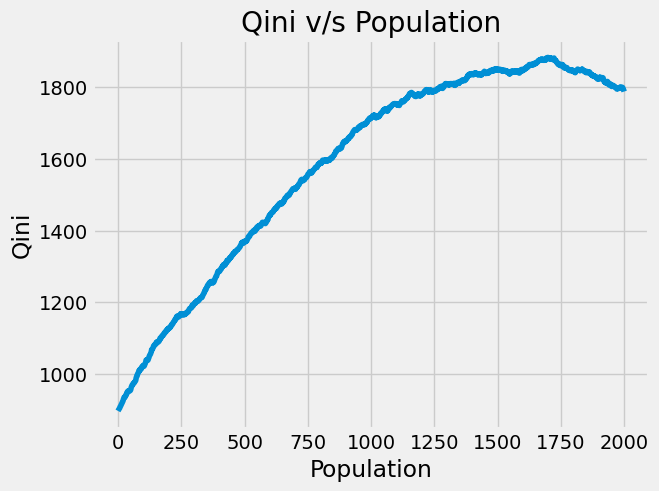

In [17]:
plt.plot(gain)
plt.xlabel('Population')
plt.ylabel('Qini')
plt.title('Qini v/s Population')
plt.show()

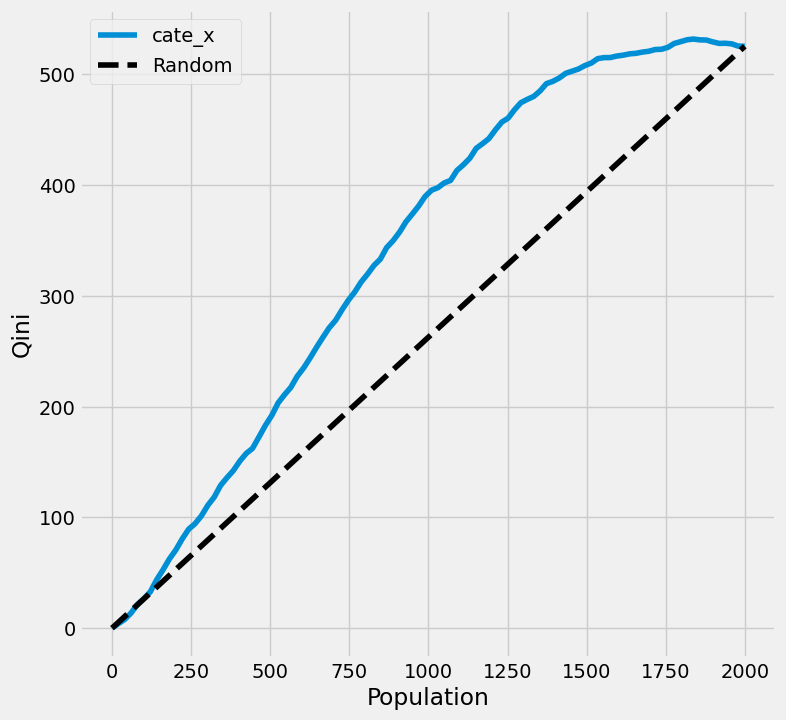

In [18]:
plot_qini(cate_df,'y','treatment')